## **Excited States by Deflation**

Minimize $H+\beta|\psi_0\rangle\langle\psi_0|$, with the overlap measured by a compute-uncompute circuit rather than read off the simulator.

### **Set Problem**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qconflib import (problem_1d, Executor, BatchedExpectation, add_deflation_block,
                      default_beta, solve, solve_excited, statevector)

n, depth = 4, 4
prob = problem_1d(n)
print(prob.label)
print(f"E0 = {prob.eigvals[0]:.5f}   E1 = {prob.eigvals[1]:.5f}   gap = {prob.gap01:.5f}")
print(f"default beta = {default_beta(prob):.3f}   (must exceed the gap)")

1D box N=16, u0=0.0 eV
E0 = 0.03405   E1 = 0.13506   gap = 0.10100
default beta = 0.500   (must exceed the gap)


### **The Deflation Circuit**

SD alone: 4 circuits per evaluation
SD + deflation: 5 circuits per evaluation


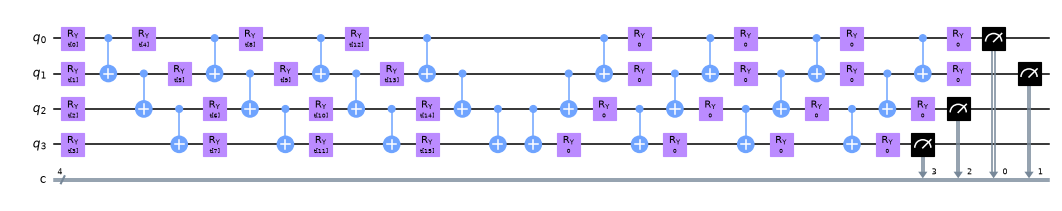

In [2]:
class _PassThrough:
    def transpile(self, qc):
        return qc

theta0_demo = np.zeros(n * depth)                       # placeholder angles, for drawing only
bx = BatchedExpectation(prob, 'SD', depth, _PassThrough())
print(f"SD alone: {bx.per_eval} circuits per evaluation")
add_deflation_block(bx, theta0_demo, default_beta(prob), _PassThrough())
print(f"SD + deflation: {bx.per_eval} circuits per evaluation")

bx.templates[-1].draw('mpl', style='clifford', fold=-1, scale=0.55)

### **Ground State, then Excited State**

Deflate against the trained $\psi_0$, not the exact one.

In [3]:
import time

t0 = time.perf_counter()
ground = solve(prob, method='SD', depth=depth, shots=2**14, seed=111,
               stages=((120, 2**14),), screen=8)
print(f"ground : trace {ground['trace']:.4f}, E0 = {ground['energy']:.5f} "
      f"(exact {prob.eigvals[0]:.5f})   [{time.perf_counter()-t0:.0f} s]")

t0 = time.perf_counter()
exc = solve_excited(prob, ground['x_opt'], method='SD', depth=depth, shots=2**14,
                    seed=111, stages=((120, 2**14),), screen=8,
                    screen_ref=prob.excited1)
print(f"excited: trace {exc['trace']:.4f}, E1 = {exc['energy']:.5f} "
      f"(exact {exc['E1_exact']:.5f})   [{time.perf_counter()-t0:.0f} s]")
print(f"         degeneracy {exc['degeneracy']}, "
      f"residual overlap |<psi0|psi1>|^2 = {exc['overlap0']:.2e}, beta = {exc['beta']:.3f}")

ground : trace 0.0337, E0 = 0.03465 (exact 0.03405)   [14 s]


excited: trace 0.9644, E1 = 0.29898 (exact 0.13506)   [18 s]
         degeneracy 1, residual overlap |<psi0|psi1>|^2 = 1.34e-03, beta = 0.500


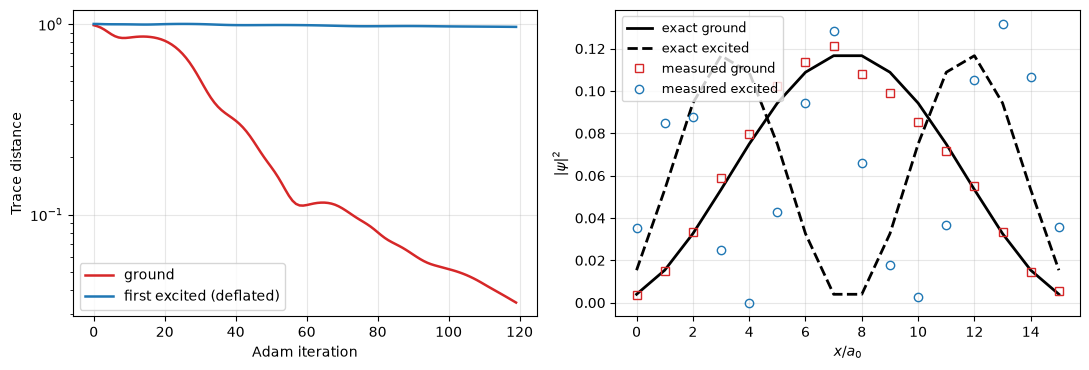

In [4]:
x = np.arange(2**n)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].semilogy([h[2] for h in ground['history']], color='#d62728', lw=1.8, label='ground')
ax[0].semilogy(exc['history'], color='#1f77b4', lw=1.8, label='first excited (deflated)')
ax[0].set_xlabel('Adam iteration'); ax[0].set_ylabel('Trace distance')
ax[0].grid(alpha=.3); ax[0].legend()

ax[1].plot(x, np.abs(prob.ground)**2, 'k-', lw=2, label='exact ground')
ax[1].plot(x, np.abs(prob.excited1)**2, 'k--', lw=2, label='exact excited')
ax[1].plot(x, ground['rho'], 's', color='#d62728', mfc='none', label='measured ground')
ax[1].plot(x, exc['rho'], 'o', color='#1f77b4', mfc='none', label='measured excited')
ax[1].set_xlabel(r'$x/a_0$'); ax[1].set_ylabel(r'$|\psi|^2$')
ax[1].grid(alpha=.3); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### **Closing the Gap with a Potential**

The gap shrinks with $u_0$ until it drops below the shot-noise floor.

In [5]:
for u0 in (0.0, 0.5, 1.0, 2.0):
    p = problem_1d(5, u0)
    print(f"u0 = {u0:4.1f} eV:  E0 = {p.eigvals[0]:.5f}  E1 = {p.eigvals[1]:.5f}  "
          f"gap = {p.gap01:.5f}")

u0 =  0.0 eV:  E0 = 0.00906  E1 = 0.03614  gap = 0.02709
u0 =  0.5 eV:  E0 = 0.08823  E1 = 0.10008  gap = 0.01185
u0 =  1.0 eV:  E0 = 0.15318  E1 = 0.15674  gap = 0.00357
u0 =  2.0 eV:  E0 = 0.25248  E1 = 0.25274  gap = 0.00027


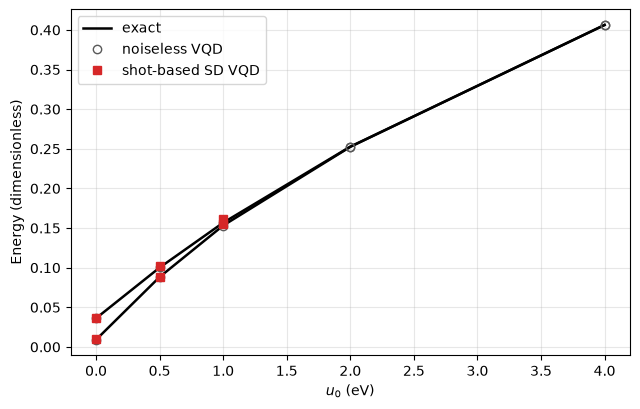

In [6]:
import json, os
V = os.path.join('paper', 'data', 'vqd')
sweep = json.load(open(f'{V}/vqd_sweep.json'))        # noiseless VQD, list of records
shots_sw = json.load(open(f'{V}/shots_sweep.json'))   # shot-based VQD per method

u = [r['u0'] for r in sweep]
plt.figure(figsize=(6.5, 4.2))
plt.plot(u, [r['E0_exact'] for r in sweep], 'k-', lw=1.8)
plt.plot(u, [r['E1_exact'] for r in sweep], 'k-', lw=1.8, label='exact')
plt.plot(u, [r['E0'] for r in sweep], 'o', color='0.35', mfc='none', label='noiseless VQD')
plt.plot(u, [r['E1'] for r in sweep], 'o', color='0.35', mfc='none')
us = [r['u0'] for r in shots_sw['methods']['SD']]
plt.plot(us, [r['E0'] for r in shots_sw['methods']['SD']], 's', color='#d62728',
         label='shot-based SD VQD')
plt.plot(us, [r['E1'] for r in shots_sw['methods']['SD']], 's', color='#d62728')
plt.xlabel(r'$u_0$ (eV)'); plt.ylabel('Energy (dimensionless)')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

In [7]:
# the gap closes faster than the solver error grows, which is what limits u0
print(f"{'u0':>5} {'gap':>10} {'E1 error':>12} {'trace1':>9}")
for r in sweep:
    sd = next((q for q in shots_sw['methods']['SD'] if abs(q['u0'] - r['u0']) < 1e-9), None)
    tr = f"{sd['trace1']:.4f}" if sd else '--'
    print(f"{r['u0']:>5.1f} {r['gap']:>10.5f} {abs(r['E1']-r['E1_exact']):>12.5f} {tr:>9}")

   u0        gap     E1 error    trace1
  0.0    0.02709      0.00008    0.0192
  0.5    0.01185      0.00016    0.0594
  1.0    0.00357      0.00008    0.0838
  2.0    0.00027      0.00016        --
  4.0    0.00000      0.00027        --


### **2D and 3D Excited States**

The 2D level is unique, the 3D level is threefold degenerate, so accuracy is scored by subspace fidelity.

In [8]:
from qconflib import problem_2d, problem_3d, subspace_fidelity

W = os.path.join('paper', 'data', 'vqd23d')
DEPTH23 = 8
p2 = problem_2d(5, 5)
p3 = problem_3d(3, 3, 3)
arch = json.load(open(f'{W}/meta.json'))

q2 = np.loadtxt(f'{W}/2d_32x32_excited_shotSD.csv', delimiter=',', skiprows=1)
q3 = np.loadtxt(f'{W}/3d_8x8x8_excited_shotSD.csv', delimiter=',', skiprows=1)
for tag, p, key in [('2-D 32x32 (anisotropic)', p2, '2d_32x32'),
                    ('3-D 8x8x8  (isotropic) ', p3, '3d_8x8x8')]:
    # recompute the fidelity from the archived parameters, signs and all
    th = np.loadtxt(f'{W}/{key}_excited_shotSD_params.csv', delimiter=',')
    fid, deg = subspace_fidelity(statevector(th, p.n, DEPTH23), p)
    a = arch[key]
    print(f"{tag}: gap {p.gap01:.5f}, {deg}-fold degenerate, "
          f"subspace fidelity {fid:.4f}, E1 relative error {a['E1_relerr']:.2e}")

2-D 32x32 (anisotropic): gap 0.02764, 1-fold degenerate, subspace fidelity 0.9902, E1 relative error 2.95e-03
3-D 8x8x8  (isotropic) : gap 0.34730, 3-fold degenerate, subspace fidelity 0.9999, E1 relative error 1.98e-04


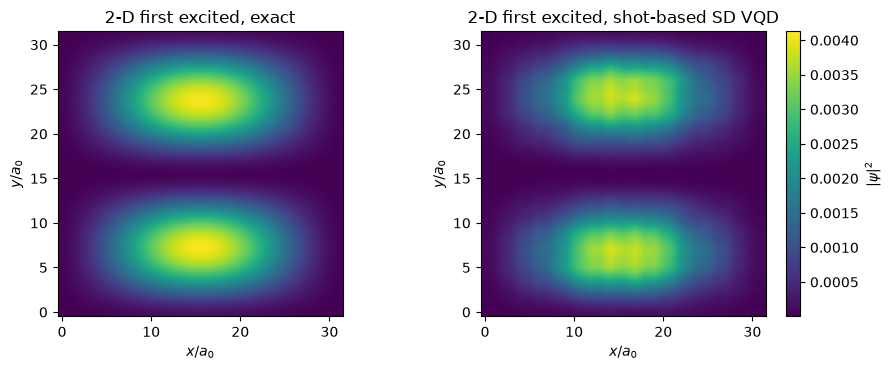

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
for k, (title, grid) in enumerate([
        ('exact', (np.abs(p2.excited1)**2).reshape(32, 32)),
        ('shot-based SD VQD', q2.reshape(32, 32))]):
    im = ax[k].imshow(grid, origin='lower', cmap='viridis', interpolation='bicubic')
    ax[k].set_title(f'2-D first excited, {title}')
    ax[k].set_xlabel(r'$x/a_0$'); ax[k].set_ylabel(r'$y/a_0$')
fig.colorbar(im, ax=ax[1], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()

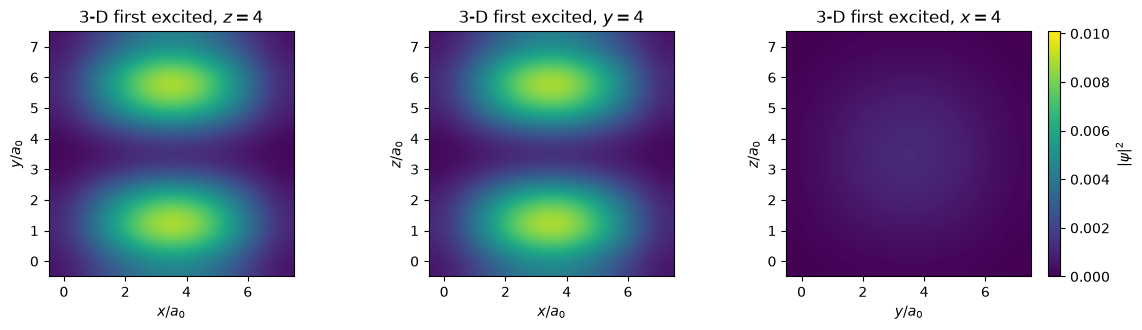

In [10]:
v3 = q3.reshape(8, 8, 8)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for k, (title, plane, xl, yl) in enumerate([
        ('$z=4$', v3[:, :, 4], r'$x/a_0$', r'$y/a_0$'),
        ('$y=4$', v3[:, 4, :], r'$x/a_0$', r'$z/a_0$'),
        ('$x=4$', v3[4, :, :], r'$y/a_0$', r'$z/a_0$')]):
    im = ax[k].imshow(plane, origin='lower', cmap='viridis', interpolation='bicubic',
                      vmin=0, vmax=v3.max())
    ax[k].set_title(f'3-D first excited, {title}'); ax[k].set_xlabel(xl); ax[k].set_ylabel(yl)
fig.colorbar(im, ax=ax[2], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()